# Surrogate model experiment

1. **Data loading** — config, load Excel (Training Data / Testing Data), split inputs/outputs, preview.  
2. **Model building** — train per-output models, evaluate, plot.

In [26]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [27]:
# --- 1. DATA LOADING (config + helpers) ---

@dataclass
class SurrogateConfig:
    excel_path: Path
    train_sheet: str
    test_sheet: str
    input_tags: Sequence[str]
    output_tags: Sequence[str]
    time_tag: str = "time"


def _split_X_y(df: pd.DataFrame, cfg: SurrogateConfig) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    feature_cols = [c for c in cfg.input_tags if c in df.columns and c != cfg.time_tag]
    missing_inputs = [c for c in cfg.input_tags if c not in df.columns]
    if missing_inputs:
        raise ValueError(f"Missing input tags in Excel: {missing_inputs!r}")
    X = df.loc[:, feature_cols].to_numpy(dtype=float)
    y_dict: Dict[str, np.ndarray] = {}
    for tag in cfg.output_tags:
        if tag not in df.columns:
            raise ValueError(f"Missing output tag in Excel: {tag!r}")
        y_dict[tag] = df[tag].to_numpy(dtype=float)
    return X, y_dict


def load_train_test(cfg: SurrogateConfig):
    excel_path = Path(cfg.excel_path)
    if not excel_path.is_file():
        raise FileNotFoundError(f"Excel file not found: {excel_path}")
    train_df = pd.read_excel(excel_path, sheet_name=cfg.train_sheet)
    test_df = pd.read_excel(excel_path, sheet_name=cfg.test_sheet)
    X_train, y_train = _split_X_y(train_df, cfg)
    X_test, y_test = _split_X_y(test_df, cfg)
    return train_df, test_df, X_train, y_train, X_test, y_test

In [28]:
# --- 2. MODEL BUILDING (train + evaluate helpers) ---

def train_baseline_models(
    X_train: np.ndarray,
    y_train: Dict[str, np.ndarray],
    n_estimators: int = 200,
    random_state: int = 0,
) -> Dict[str, RandomForestRegressor]:
    models: Dict[str, RandomForestRegressor] = {}
    for tag, y in y_train.items():
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
        model.fit(X_train, y)
        models[tag] = model
    return models


def train_xgb_models(
    X_train: np.ndarray,
    y_train: Dict[str, np.ndarray],
    n_estimators: int = 500,
    random_state: int = 0,
    **kwargs,
) -> Dict[str, XGBRegressor]:
    models: Dict[str, XGBRegressor] = {}
    for tag, y in y_train.items():
        model = XGBRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1, **kwargs)
        model.fit(X_train, y)
        models[tag] = model
    return models


def evaluate_models(
    models,
    X: np.ndarray,
    y_true: Dict[str, np.ndarray],
) -> Dict[str, Dict[str, float]]:
    metrics: Dict[str, Dict[str, float]] = {}
    for tag, model in models.items():
        if tag not in y_true:
            continue
        y_pred = model.predict(X)
        yt = y_true[tag]
        mae = float(mean_absolute_error(yt, y_pred))
        mse = float(mean_squared_error(yt, y_pred))
        rmse = float(np.sqrt(mse))
        r2 = float(r2_score(yt, y_pred))
        metrics[tag] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    return metrics

## 1. Data loading

### 1.1 Config

Edit sheet names and tags to match your Excel. Time column is never used as a feature.

In [29]:
cfg = SurrogateConfig(
    excel_path=Path("simple_dynamic_process.xlsx"),
    train_sheet="Training Data",
    test_sheet="Testing Data",
    input_tags=["U1", "U2"],
    output_tags=["Y1", "Y2"],
    time_tag="Time",
)

### 1.2 Load and preview

In [30]:
train_df, test_df, X_train, y_train, X_test, y_test = load_train_test(cfg)
print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
print("X_train shape:", X_train.shape)
train_df.head()

Train shape: (2001, 5) | Test shape: (2001, 5)
X_train shape: (2001, 2)


,Time,U1,U2,Y1,Y2
0,0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0


In [31]:
test_df.head()

,Time,U1,U2,Y1,Y2
0,0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0


## 2. Model building

### 2.1 Train

One Random Forest per output. Tweak `n_estimators` or try other regressors here.

In [32]:
models = train_baseline_models(X_train, y_train, n_estimators=200)
models_xgb = train_xgb_models(X_train, y_train, n_estimators=500)

### 2.2 Evaluate

In [33]:
train_metrics = evaluate_models(models, X_train, y_train)
train_metrics_xgb = evaluate_models(models_xgb, X_train, y_train)
print("Train — Random Forest")
display(pd.DataFrame(train_metrics).T)
print("Train — XGBoost")
display(pd.DataFrame(train_metrics_xgb).T)

Train — Random Forest


,MAE,RMSE,R2
Y1,0.416125,1.251587,0.894873
Y2,1.029961,3.294825,0.933118


Train — XGBoost


,MAE,RMSE,R2
Y1,0.415546,1.250509,0.895054
Y2,1.044316,3.290368,0.933299


In [34]:
test_metrics = evaluate_models(models, X_test, y_test)
test_metrics_xgb = evaluate_models(models_xgb, X_test, y_test)
print("Test — Random Forest")
display(pd.DataFrame(test_metrics).T)
print("Test — XGBoost")
display(pd.DataFrame(test_metrics_xgb).T)

Test — Random Forest


,MAE,RMSE,R2
Y1,2.002185,2.849283,0.548094
Y2,6.614765,9.109206,0.582188


Test — XGBoost


,MAE,RMSE,R2
Y1,2.233856,3.119775,0.458219
Y2,7.042895,9.754998,0.520846


### 2.3 Plots

Top row: train actual vs predicted over sample index. Bottom row: test actual vs predicted (scatter).

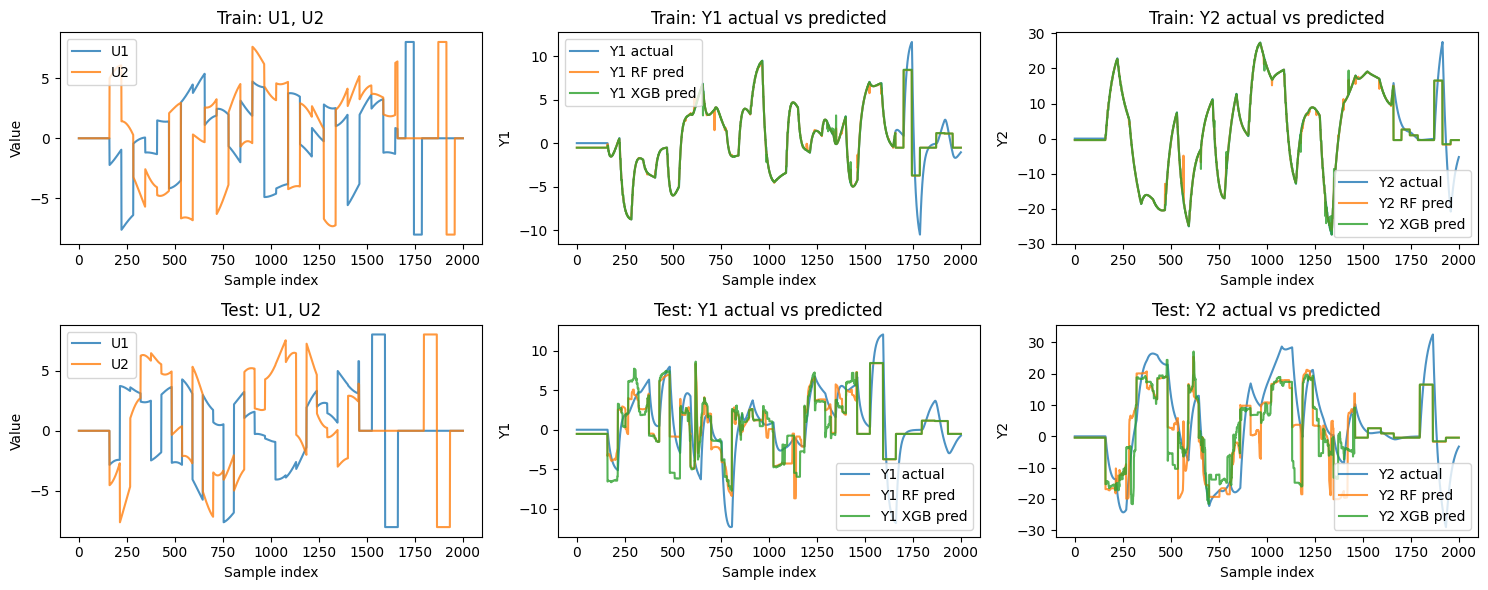

In [35]:
# 2 rows (train, test) x 3 cols (U1 U2, Y1 actual vs pred, Y2 actual vs pred). RF and XGB both shown.
n_out = len(cfg.output_tags)
fig, axes = plt.subplots(2, 1 + n_out, figsize=(5 * (1 + n_out), 6))

idx_train = np.arange(len(train_df))
idx_test = np.arange(len(test_df))

# ---- Row 0: TRAIN ----
for tag in cfg.input_tags:
    axes[0, 0].plot(idx_train, train_df[tag], label=tag, alpha=0.8)
axes[0, 0].set_title("Train: U1, U2")
axes[0, 0].set_xlabel("Sample index")
axes[0, 0].set_ylabel("Value")
axes[0, 0].legend()

for i, tag in enumerate(cfg.output_tags):
    ax = axes[0, 1 + i]
    y_actual = y_train[tag]
    ax.plot(idx_train, y_actual, label=f"{tag} actual", alpha=0.8)
    ax.plot(idx_train, models[tag].predict(X_train), label=f"{tag} RF pred", alpha=0.8)
    ax.plot(idx_train, models_xgb[tag].predict(X_train), label=f"{tag} XGB pred", alpha=0.8)
    ax.set_title(f"Train: {tag} actual vs predicted")
    ax.set_xlabel("Sample index")
    ax.set_ylabel(tag)
    ax.legend()

# ---- Row 1: TEST ----
for tag in cfg.input_tags:
    axes[1, 0].plot(idx_test, test_df[tag], label=tag, alpha=0.8)
axes[1, 0].set_title("Test: U1, U2")
axes[1, 0].set_xlabel("Sample index")
axes[1, 0].set_ylabel("Value")
axes[1, 0].legend()

for i, tag in enumerate(cfg.output_tags):
    ax = axes[1, 1 + i]
    y_actual = y_test[tag]
    ax.plot(idx_test, y_actual, label=f"{tag} actual", alpha=0.8)
    ax.plot(idx_test, models[tag].predict(X_test), label=f"{tag} RF pred", alpha=0.8)
    ax.plot(idx_test, models_xgb[tag].predict(X_test), label=f"{tag} XGB pred", alpha=0.8)
    ax.set_title(f"Test: {tag} actual vs predicted")
    ax.set_xlabel("Sample index")
    ax.set_ylabel(tag)
    ax.legend()

fig.tight_layout()
plt.show()

## 3. Dynamic model (lagged inputs and outputs)

Use current and past inputs (U1, U2) and past outputs (Y1, Y2) as features so the model can capture dynamics.

In [36]:
def build_lagged_X_y(
    df: pd.DataFrame,
    cfg: SurrogateConfig,
    input_lags: int = 0,
    output_lags: int = 1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray], int]:
    """
    Build feature matrix with lagged inputs and outputs.
    - input_lags: 0 = current inputs only; 1 = current + U(t-1); 2 = current + 2 lags, etc.
    - output_lags: 1 = use Y(t-1); 2 = use Y(t-1), Y(t-2), etc.
    Returns X, y_dict, max_lag. First max_lag rows are dropped (no history).
    """
    input_cols = [c for c in cfg.input_tags if c in df.columns and c != cfg.time_tag]
    max_lag = max(input_lags, output_lags)
    n = len(df)
    if n <= max_lag:
        raise ValueError(f"Need more than max_lag={max_lag} rows; got {n}")

    rows = []
    for i in range(max_lag, n):
        feats = []
        for lag in range(input_lags + 1):
            for col in input_cols:
                feats.append(df[col].iloc[i - lag])
        for lag in range(1, output_lags + 1):
            for col in cfg.output_tags:
                feats.append(df[col].iloc[i - lag])
        rows.append(feats)
    X = np.array(rows, dtype=float)
    y_dict = {tag: df[tag].iloc[max_lag:].to_numpy(dtype=float) for tag in cfg.output_tags}
    return X, y_dict, max_lag

### 3.1 Lag config and build lagged data

Set how many past steps of inputs and outputs to use. Then build X_train_dyn, y_train_dyn, X_test_dyn, y_test_dyn (and max_lag for plotting).

In [45]:
input_lags = 5   # 0 = current U only; 1 = current + U(t-1); 2 = + U(t-2), etc.
output_lags = 5  # 1 = use Y(t-1); 2 = use Y(t-1), Y(t-2), etc.

X_train_dyn, y_train_dyn, max_lag = build_lagged_X_y(train_df, cfg, input_lags, output_lags)
X_test_dyn, y_test_dyn, _ = build_lagged_X_y(test_df, cfg, input_lags, output_lags)
print(f"Lagged: max_lag={max_lag}. X_train_dyn shape: {X_train_dyn.shape}, X_test_dyn shape: {X_test_dyn.shape}")

Lagged: max_lag=5. X_train_dyn shape: (1996, 22), X_test_dyn shape: (1996, 22)


### 3.2 Train dynamic models (RF + XGB)

In [46]:
models_dyn = train_baseline_models(X_train_dyn, y_train_dyn, n_estimators=200)
models_xgb_dyn = train_xgb_models(X_train_dyn, y_train_dyn, n_estimators=200)

### 3.3 Evaluate dynamic models

In [47]:
train_metrics_dyn = evaluate_models(models_dyn, X_train_dyn, y_train_dyn)
train_metrics_xgb_dyn = evaluate_models(models_xgb_dyn, X_train_dyn, y_train_dyn)
test_metrics_dyn = evaluate_models(models_dyn, X_test_dyn, y_test_dyn)
test_metrics_xgb_dyn = evaluate_models(models_xgb_dyn, X_test_dyn, y_test_dyn)
print("Dynamic — Train RF"); display(pd.DataFrame(train_metrics_dyn).T)
print("Dynamic — Train XGB"); display(pd.DataFrame(train_metrics_xgb_dyn).T)
print("Dynamic — Test RF"); display(pd.DataFrame(test_metrics_dyn).T)
print("Dynamic — Test XGB"); display(pd.DataFrame(test_metrics_xgb_dyn).T)

Dynamic — Train RF


,MAE,RMSE,R2
Y1,0.021779,0.053981,0.999805
Y2,0.044964,0.086768,0.999954


Dynamic — Train XGB


,MAE,RMSE,R2
Y1,0.005435,0.007748,0.999996
Y2,0.014159,0.020231,0.999997


Dynamic — Test RF


,MAE,RMSE,R2
Y1,0.137089,0.341871,0.993510
Y2,0.234825,0.554152,0.998457


Dynamic — Test XGB


,MAE,RMSE,R2
Y1,0.139073,0.392362,0.991451
Y2,0.227800,0.507018,0.998709


### 3.4 Plots (dynamic) — indices aligned from max_lag

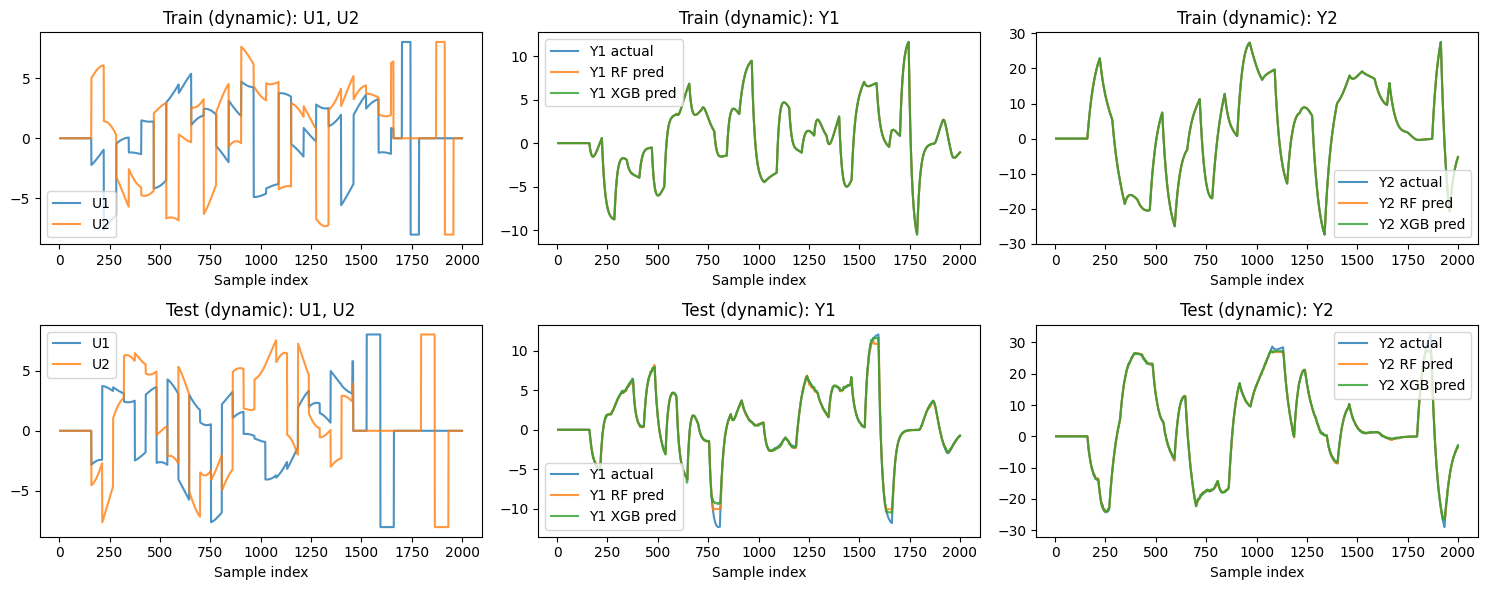

In [48]:
n_out = len(cfg.output_tags)
fig, axes = plt.subplots(2, 1 + n_out, figsize=(5 * (1 + n_out), 6))
idx_train_dyn = np.arange(max_lag, len(train_df))
idx_test_dyn = np.arange(max_lag, len(test_df))

# Row 0: TRAIN (dynamic)
for tag in cfg.input_tags:
    axes[0, 0].plot(idx_train_dyn, train_df[tag].iloc[max_lag:], label=tag, alpha=0.8)
axes[0, 0].set_title("Train (dynamic): U1, U2")
axes[0, 0].set_xlabel("Sample index")
axes[0, 0].legend()

for i, tag in enumerate(cfg.output_tags):
    ax = axes[0, 1 + i]
    ax.plot(idx_train_dyn, y_train_dyn[tag], label=f"{tag} actual", alpha=0.8)
    ax.plot(idx_train_dyn, models_dyn[tag].predict(X_train_dyn), label=f"{tag} RF pred", alpha=0.8)
    ax.plot(idx_train_dyn, models_xgb_dyn[tag].predict(X_train_dyn), label=f"{tag} XGB pred", alpha=0.8)
    ax.set_title(f"Train (dynamic): {tag}")
    ax.set_xlabel("Sample index")
    ax.legend()

# Row 1: TEST (dynamic)
for tag in cfg.input_tags:
    axes[1, 0].plot(idx_test_dyn, test_df[tag].iloc[max_lag:], label=tag, alpha=0.8)
axes[1, 0].set_title("Test (dynamic): U1, U2")
axes[1, 0].set_xlabel("Sample index")
axes[1, 0].legend()

for i, tag in enumerate(cfg.output_tags):
    ax = axes[1, 1 + i]
    ax.plot(idx_test_dyn, y_test_dyn[tag], label=f"{tag} actual", alpha=0.8)
    ax.plot(idx_test_dyn, models_dyn[tag].predict(X_test_dyn), label=f"{tag} RF pred", alpha=0.8)
    ax.plot(idx_test_dyn, models_xgb_dyn[tag].predict(X_test_dyn), label=f"{tag} XGB pred", alpha=0.8)
    ax.set_title(f"Test (dynamic): {tag}")
    ax.set_xlabel("Sample index")
    ax.legend()

fig.tight_layout()
plt.show()